# ML/01 — PCA + Feature Importance

Before clustering, understand the structure of the feature space:
1. PCA — how many dimensions capture most variance? Which features drive them?
2. Feature importance via Random Forest on a synthetic task (landscape vs. random)
   to rank which variables carry the most geographic signal.

No labels needed. PCA and RF importance work on the raw feature matrix.

**Outputs:**
- `data/processed/pca_coords.pkl` — cell coordinates in PC space
- `img/ML01_pca_variance.png` — scree plot + PC1/PC2 biplot
- `img/ML01_pca_map.png` — cells colored by PC1 and PC2
- `img/ML01_feature_importance.png` — RF importance ranking

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')
IMG.mkdir(exist_ok=True)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load data

In [2]:
features        = pd.read_pickle(PROC / 'features.pkl')
features_scaled = pd.read_pickle(PROC / 'features_scaled.pkl')
hex_grid        = gpd.read_file(RAW / 'hex_grid.gpkg')

feature_cols = [c for c in features_scaled.columns if c != 'cell_id']
X = features_scaled[feature_cols].values

print(f'Feature matrix: {X.shape}')
print(f'Features: {feature_cols}')

Feature matrix: (8648, 23)
Features: ['elev_mean', 'elev_min', 'elev_max', 'elev_std', 'slope_mean', 'aspect_cos', 'aspect_sin', 'relief', 'ndvi_std', 'tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range', 'ph', 'soc', 'sand', 'silt', 'clay', 'cec']


## 2. PCA

In [3]:
pca = PCA()
pca.fit(X)

explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n90 = np.argmax(cumulative >= 0.90) + 1
n95 = np.argmax(cumulative >= 0.95) + 1
print(f'PCs to explain 90% variance: {n90}')
print(f'PCs to explain 95% variance: {n95}')
print()
for i, (e, c) in enumerate(zip(explained[:10], cumulative[:10])):
    print(f'  PC{i+1:02d}:  {e*100:5.1f}%  (cumulative {c*100:5.1f}%)')

PCs to explain 90% variance: 6
PCs to explain 95% variance: 8

  PC01:   55.0%  (cumulative  55.0%)
  PC02:   16.5%  (cumulative  71.5%)
  PC03:    8.6%  (cumulative  80.1%)
  PC04:    4.9%  (cumulative  85.0%)
  PC05:    4.2%  (cumulative  89.2%)
  PC06:    3.6%  (cumulative  92.8%)
  PC07:    1.7%  (cumulative  94.6%)
  PC08:    1.3%  (cumulative  95.9%)
  PC09:    1.2%  (cumulative  97.1%)
  PC10:    0.8%  (cumulative  97.9%)


In [ ]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained)+1), explained*100, color='#4a90d9', alpha=0.8)
axes[0].plot(range(1, len(explained)+1), cumulative*100, 'k-o', markersize=4)
axes[0].axhline(90, color='red', linestyle='--', linewidth=0.8, label='90%')
axes[0].axhline(95, color='orange', linestyle='--', linewidth=0.8, label='95%')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Scree plot')
axes[0].legend()
axes[0].set_xlim(0.5, min(len(explained)+0.5, 20))

# PC1 vs PC2 biplot (loadings)
# Scale arrows by sqrt(eigenvalue) so longer arrow = bigger contribution
scale = np.sqrt(pca.explained_variance_[:2])
loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
ax = axes[1]
max_val = loadings.abs().values.max() * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.axhline(0, color='#cccccc', linewidth=0.8)
ax.axvline(0, color='#cccccc', linewidth=0.8)
for feat, row in loadings.iterrows():
    ax.annotate('', xy=(row.PC1, row.PC2), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#4a90d9', lw=1.5))
    ax.text(row.PC1 * 1.12, row.PC2 * 1.12, feat, fontsize=7, ha='center')
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PC1 / PC2 loadings biplot')

plt.tight_layout()
plt.savefig('../img/ML01_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML01_pca_variance.png')

## 3. Map cells by PC score

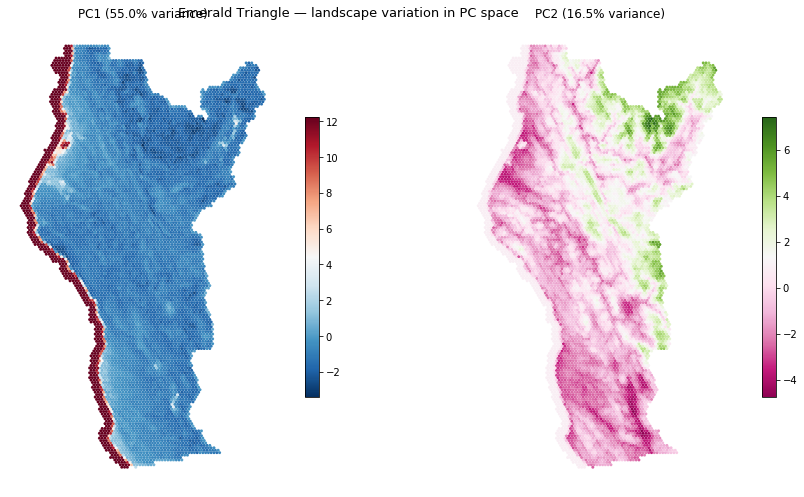

Saved img/ML01_pca_map.png


In [5]:
pca_k = PCA(n_components=min(n95, 10))
X_pca = pca_k.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)
pca_df.insert(0, 'cell_id', features_scaled['cell_id'].values)

hex_pca = hex_grid.merge(pca_df, on='cell_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pc, cmap in zip(axes, ['PC1', 'PC2'], ['RdBu_r', 'PiYG']):
    hex_pca.plot(column=pc, ax=ax, cmap=cmap, legend=True,
                 legend_kwds={'shrink': 0.6}, linewidth=0)
    ax.set_title(f'{pc} ({pca_k.explained_variance_ratio_[int(pc[2:])-1]*100:.1f}% variance)',
                 fontsize=12)
    ax.set_axis_off()

plt.suptitle('Emerald Triangle — landscape variation in PC space', fontsize=13)
plt.tight_layout()
plt.savefig('../img/ML01_pca_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML01_pca_map.png')

## 4. Feature importance via Random Forest

No labels, so we create a synthetic task: can a RF distinguish real cells
from randomly shuffled cells? Features that survive shuffling carry real
geographic structure; importance rankings show which drive the landscape signal.

In [6]:
rng = np.random.RandomState(746837645)

# Real cells = class 1, column-wise shuffled cells = class 0
X_shuffled = X.copy()
for col in range(X_shuffled.shape[1]):
    X_shuffled[:, col] = rng.permutation(X_shuffled[:, col])

X_rf = np.vstack([X, X_shuffled])
y_rf = np.array([1] * len(X) + [0] * len(X_shuffled))

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=746837645, n_jobs=-1)
scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring='roc_auc')
print(f'RF synthetic task AUC: {scores.mean():.3f} ± {scores.std():.3f}')
print('(>0.5 means features carry real geographic structure)')

rf.fit(X_rf, y_rf)
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

RF synthetic task AUC: 0.962 ± 0.074
(>0.5 means features carry real geographic structure)


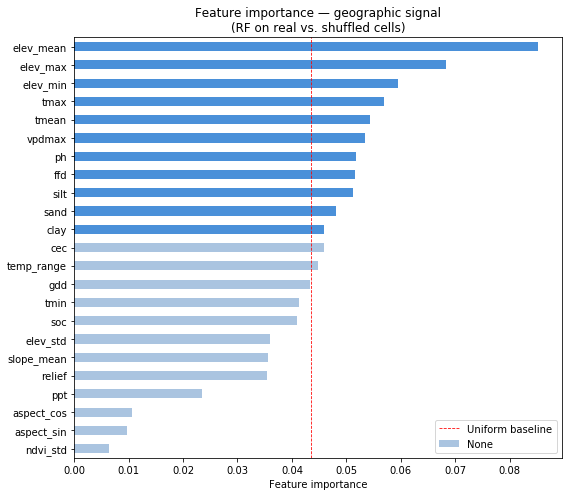

Saved img/ML01_feature_importance.png

Top 5 features:
elev_mean    0.0853
elev_max     0.0682
elev_min     0.0594
tmax         0.0569
tmean        0.0543


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#4a90d9' if imp > importance.median() else '#aac4e0'
          for imp in importance.values]
importance.plot(kind='barh', ax=ax, color=colors)
ax.axvline(1/len(feature_cols), color='red', linestyle='--',
           linewidth=0.8, label='Uniform baseline')
ax.set_xlabel('Feature importance')
ax.set_title('Feature importance — geographic signal\n(RF on real vs. shuffled cells)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../img/ML01_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML01_feature_importance.png')
print()
print('Top 5 features:')
print(importance.tail(5).iloc[::-1].round(4).to_string())

## 5. Save PCA output

In [8]:
pca_df.to_pickle(PROC / 'pca_coords.pkl')
with open(PROC / 'pca_model.pkl', 'wb') as f:
    pickle.dump(pca_k, f)

print('Saved:')
print('  data/processed/pca_coords.pkl')
print('  data/processed/pca_model.pkl')
print()
print(f'Using {X_pca.shape[1]} PCs ({pca_k.explained_variance_ratio_.sum()*100:.1f}% variance)')
print()
print('Next: ML/02_clustering.ipynb — k-means on PCA-reduced features')

Saved:
  data/processed/pca_coords.pkl
  data/processed/pca_model.pkl

Using 8 PCs (95.9% variance)

Next: ML/02_clustering.ipynb — k-means on PCA-reduced features
